## Seq2Seq + Attention 实现详解

## 核心思想

Seq2Seq（Sequence-to-Sequence）模型用于处理**输入序列和输出序列长度不同**的任务，如机器翻译、文本摘要等。

### 模型结构

```
输入序列 → [Encoder] → 上下文向量 → [Decoder] → 输出序列
                ↑                          ↑
           GRU 编码器                 GRU 解码器
                                  + Attention 机制
```

### Attention 机制

传统的 Seq2Seq 将整个输入序列压缩为一个固定长度的向量，这会导致信息瓶颈。Attention 机制让解码器在每一步都能**关注输入序列的不同部分**：

$$\text{attention}(s_{t-1}, h_j) = v^T \tanh(W_a s_{t-1} + U_a h_j)$$

其中 $s_{t-1}$ 是解码器的隐藏状态，$h_j$ 是编码器的第 $j$ 个隐藏状态。

## 1. 数据准备

我们构建一个简单的数字序列到英文单词的翻译任务：
- 输入：`"1 2 3"` → 输出：`"one two three"`

### 特殊 token
- `<pad>`：填充token，用于对齐序列长度
- `<sos>`：序列开始token（Start Of Sequence）
- `<eos>`：序列结束token（End Of Sequence）

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [8]:
# 构建词汇表
src_vocab = ['<pad>', '<sos>', '<eos>'] + [str(i) for i in range(10)] + ['我', '是', '一', '名', '学', '生']
tgt_vocab = ['<pad>', '<sos>', '<eos>'] + ['zero','one','two','three','four','five','six','seven','eight','nine','I','am', 'a', 'student']

# 词汇表映射
src_to_idx = {w: i for i, w in enumerate(src_vocab)}
tgt_to_idx = {w: i for i, w in enumerate(tgt_vocab)}
idx_to_tgt = {i: w for w, i in tgt_to_idx.items()}

src_vocab_size, tgt_vocab_size = len(src_vocab), len(tgt_vocab)

print(f"源词汇表: {src_vocab}")
print(f"目标词汇表: {tgt_vocab}")
print(f"源词汇表大小: {src_vocab_size}")
print(f"目标词汇表大小: {tgt_vocab_size}")
print(src_to_idx)

源词汇表: ['<pad>', '<sos>', '<eos>', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '我', '是', '一', '名', '学', '生']
目标词汇表: ['<pad>', '<sos>', '<eos>', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'I', 'am', 'a', 'student']
源词汇表大小: 19
目标词汇表大小: 17
{'<pad>': 0, '<sos>': 1, '<eos>': 2, '0': 3, '1': 4, '2': 5, '3': 6, '4': 7, '5': 8, '6': 9, '7': 10, '8': 11, '9': 12, '我': 13, '是': 14, '一': 15, '名': 16, '学': 17, '生': 18}


In [9]:
# 训练数据
data = [
    ("1 2 3", "one two three"),
    ("4 5", "four five"),
    ("9 0", "nine zero"),
    ("3 1 4", "three one four"),
    ("我 是 一 名 学 生", "I am a student")
]
print(type(data[0]))
print("训练数据:")
for src, tgt in data:
    print(f"  {src} -> {tgt}")

<class 'tuple'>
训练数据:
  1 2 3 -> one two three
  4 5 -> four five
  9 0 -> nine zero
  3 1 4 -> three one four
  我 是 一 名 学 生 -> I am a student


In [10]:
def encode(seq, vocab, max_len=10):
    """
    将文本序列编码为索引序列
    
    格式: <sos> + tokens + <eos> + <pad>...
    """
    ids = [vocab['<sos>']] + [vocab.get(c, vocab['<pad>']) for c in seq.split()] + [vocab['<eos>']]
    # 截断或填充到固定长度
    ids = ids[:max_len] + [vocab['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids)

max_len = 10
src_seq = [encode(s, src_to_idx) for s, _ in data]
tgt_seq = [encode(t, tgt_to_idx) for _, t in data]

print("编码示例:")
print(f"  '我 是 一 名 学 生' -> {src_seq[4]}")
print(f"  'one two three' -> {tgt_seq[0]}")
print(f"\n  <sos>=2, <eos>=3, <pad>=0")

编码示例:
  '我 是 一 名 学 生' -> tensor([ 1, 13, 14, 15, 16, 17, 18,  2,  0,  0])
  'one two three' -> tensor([1, 4, 5, 6, 2, 0, 0, 0, 0, 0])

  <sos>=2, <eos>=3, <pad>=0


## 2. Encoder（编码器）

编码器使用 GRU 处理输入序列，输出：
- `outputs`：每个时间步的隐藏状态 (B, L, H)
- `hidden`：最后一个时间步的隐藏状态 (1, B, H)，作为解码器的初始状态

```
输入: [B, L] → Embedding → [B, L, E] → GRU → outputs: [B, L, H], hidden: [1, B, H]
```

In [11]:
class Encoder(nn.Module):
    """
    编码器：将输入序列编码为隐藏状态序列
    
    结构: Embedding -> GRU
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # padding_idx=0 忽略 <pad>
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    
    def forward(self, x):
        # x: (B, L) 输入序列索引
        emb = self.embed(x)                     # (B, L, E) 嵌入
        outputs, hidden = self.gru(emb)         # outputs: (B, L, H), hidden: (1, B, H)
        return outputs, hidden

## 3. Attention 机制

### Bahdanau Attention (加性注意力)

Attention 的核心思想是：解码器在预测每个词时，应该**关注输入序列的不同部分**。

计算步骤：
1. 将解码器隐藏状态 $s_{t-1}$ 扩展到与编码器输出相同的序列长度
2. 拼接 $[s_{t-1}; h_j]$，通过线性层 + tanh 得到能量值
3. 通过 softmax 得到注意力权重
4. 用注意力权重对编码器输出加权求和，得到上下文向量

$$\text{energy}_j = v^T \tanh(W_a s_{t-1} + U_a h_j)$$
$$\alpha_j = \frac{\exp(\text{energy}_j)}{\sum_k \exp(\text{energy}_k)}$$
$$c_t = \sum_j \alpha_j h_j$$

In [12]:
class Attention(nn.Module):
    """
    Bahdanau Attention (加性注意力)
    
    输入: decoder_hidden (1, B, H), encoder_outputs (B, L, H)
    输出: context (B, 1, H), attention_weights (B, L, 1)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        # 线性层：将 [decoder_hidden; encoder_output] 映射到标量能量值
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (1, B, H) -> (B, 1, H)
        decoder_hidden = decoder_hidden.squeeze(0).unsqueeze(1)
        
        src_len = encoder_outputs.shape[1]
        
        # 将 decoder_hidden 扩展到与 encoder_outputs 相同的序列长度
        # (B, 1, H) -> (B, L, H)
        decoder_hidden_expanded = decoder_hidden.expand(-1, src_len, -1)
        
        # 计算能量值：tanh(W * [decoder_hidden; encoder_output])
        # (B, L, 2H) -> (B, L, 1)
        energy = torch.tanh(self.attn(torch.cat((decoder_hidden_expanded, encoder_outputs), dim=2)))
        
        # 注意力权重：softmax over src_len
        attention_weights = torch.softmax(energy, dim=1)  # (B, L, 1)
        
        # 上下文向量：注意力权重加权求和
        # (B, 1, L) @ (B, L, H) -> (B, 1, H)
        context = torch.bmm(attention_weights.permute(0, 2, 1), encoder_outputs)
        
        return context, attention_weights

## 4. Decoder（解码器）

解码器在每一步：
1. 将当前输入词嵌入
2. 通过 Attention 获取上下文向量
3. 将嵌入和上下文向量拼接，输入 GRU
4. 通过线性层预测下一个词

```
输入: (B, 1) → Embedding → (B, 1, E)
                                    ↓
context: (B, 1, H) ← Attention ← encoder_outputs
                                    ↓
                            concat → (B, 1, E+H)
                                    ↓
                                  GRU → (B, 1, H)
                                    ↓
                              Linear → (B, vocab_size)
```

In [13]:
class Decoder(nn.Module):
    """
    解码器：结合 Attention 机制逐词生成输出序列
    
    结构: Embedding + Attention -> GRU -> Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # GRU 输入维度 = embed_dim + hidden_dim（嵌入 + 上下文向量）
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)
        self.attn = Attention(hidden_dim)
    
    def forward(self, trg, encoder_outputs, hidden):
        """
        trg: (B, 1) 当前时间步的输入词
        encoder_outputs: (B, L, H) 编码器所有时间步的输出
        hidden: (1, B, H) 上一个时间步的隐藏状态
        """
        # 嵌入当前输入词
        emb = self.embed(trg)                           # (B, 1, E)
        
        # Attention: 获取上下文向量
        context, attn_weights = self.attn(hidden, encoder_outputs)  # context: (B, 1, H)
        
        # 拼接嵌入和上下文向量
        rnn_input = torch.cat((emb, context), dim=2)    # (B, 1, E+H)
        
        # GRU 更新
        output, hidden = self.gru(rnn_input, hidden)    # output: (B, 1, H)
        
        # 预测下一个词
        pred = self.out(output.squeeze(1))              # (B, vocab_size)
        
        return pred, hidden, attn_weights

## 5. Seq2Seq 整体模型

### Teacher Forcing

在训练时，解码器的输入可以选择使用**真实的上一个词**（teacher forcing）或**模型自己的预测**：
- `teacher_forcing_ratio=0.5` 表示 50% 的概率使用真实标签
- 使用 teacher forcing 可以加速训练，但可能导致训练和推理时的分布不匹配

### 训练流程
```
1. 编码器处理输入序列 → 编码器输出 + 初始隐藏状态
2. 解码器以 <sos> 为起始，逐步预测
3. 每一步的输入 = 真实标签（概率0.5）或模型预测
4. 最终输出所有时间步的预测概率
```

In [14]:
class Seq2Seq(nn.Module):
    """
    Seq2Seq 整体模型
    
    封装 Encoder + Decoder，处理完整的序列到序列转换
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src: (B, L_src) 源序列
        trg: (B, L_tgt) 目标序列
        teacher_forcing_ratio: 使用真实标签的概率
        """
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.out.out_features
        
        # 存储所有时间步的输出
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size)
        
        # 编码器处理输入
        encoder_outputs, hidden = self.encoder(src)
        
        # 解码器的第一个输入是 <sos>
        input_token = trg[:, 0].unsqueeze(1)   # (B, 1)
        
        # 逐时间步解码
        for t in range(1, trg_len):
            pred, hidden, _ = self.decoder(input_token, encoder_outputs, hidden)
            outputs[:, t, :] = pred
            
            # Teacher Forcing: 以一定概率使用真实标签
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1)  # 模型预测的最可能词
            
            # 下一步输入：真实标签（teacher forcing）或模型预测
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1.unsqueeze(1)
        
        return outputs

## 6. 训练模型

In [15]:
# 超参数
embed_dim = 32
hidden_dim = 64

# 创建模型
encoder = Encoder(src_vocab_size, embed_dim, hidden_dim)
decoder = Decoder(tgt_vocab_size, embed_dim, hidden_dim)
model = Seq2Seq(encoder, decoder)

# 优化器和损失函数
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore_index=0 忽略 <pad> 的损失

# 准备数据
src_tensors = torch.stack(src_seq)
tgt_tensors = torch.stack(tgt_seq)

print(f"模型结构:")
print(model)
print(f"\n参数总量: {sum(p.numel() for p in model.parameters()):,}")

模型结构:
Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(19, 32, padding_idx=0)
    (gru): GRU(32, 64, batch_first=True)
  )
  (decoder): Decoder(
    (embed): Embedding(17, 32, padding_idx=0)
    (gru): GRU(96, 64, batch_first=True)
    (out): Linear(in_features=64, out_features=17, bias=True)
    (attn): Attention(
      (attn): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)

参数总量: 52,306


In [16]:
epochs = 200
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # 前向传播
    output = model(src_tensors, tgt_tensors, teacher_forcing_ratio=0.5)
    
    # 计算损失（忽略 <sos> 位置，从第2个位置开始）
    # output: (B, L, vocab_size) -> (B*L, vocab_size)
    # tgt_tensors: (B, L) -> (B*L)
    loss = criterion(output[:, 1:].reshape(-1, tgt_vocab_size), tgt_tensors[:, 1:].reshape(-1))
    
    # 反向传播
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}, Loss: {loss.item():.4f}")

Epoch  50, Loss: 0.0135
Epoch 100, Loss: 0.0035
Epoch 150, Loss: 0.0021
Epoch 200, Loss: 0.0014


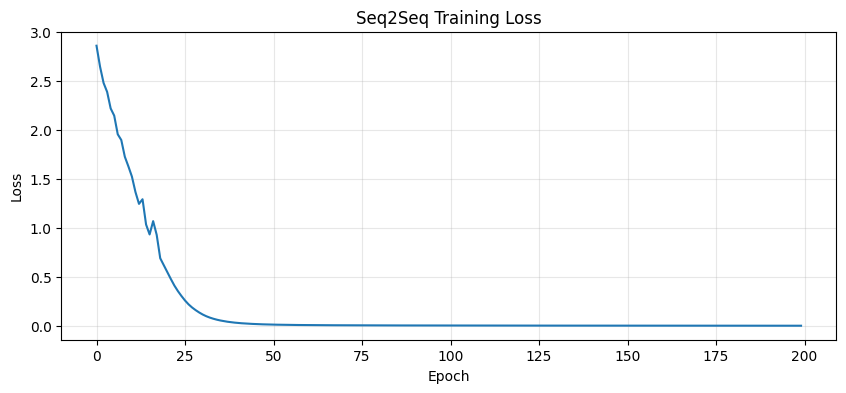

In [18]:
# 绘制损失曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Seq2Seq Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 7. 推理（翻译）

推理时，模型**不使用 teacher forcing**，而是完全依赖自己的预测：

1. 编码器处理输入序列
2. 以 `<sos>` 为起始，逐步预测
3. 每一步使用模型自己的预测作为下一步输入
4. 遇到 `<eos>` 或达到最大长度时停止

In [20]:
def translate(src_str):
    """
    翻译函数：将数字序列转换为英文单词序列
    """
    # 编码输入
    src_t = encode(src_str, src_to_idx).unsqueeze(0)
    
    with torch.no_grad():
        # 编码器处理
        encoder_outputs, hidden = model.encoder(src_t)
        【
        # 从 <sos> 开始
        input_token = torch.tensor([[tgt_to_idx['<sos>']]])
        result = []
        
        # 逐步解码
        for _ in range(max_len):
            pred, hidden, _ = model.decoder(input_token, encoder_outputs, hidden)
            next_token = pred.argmax(1).item()
            
            # 遇到 <eos> 停止
            if next_token == tgt_to_idx['<eos>']:
                break
            
            result.append(idx_to_tgt[next_token])
            input_token = torch.tensor([[next_token]])
    
    return ' '.join(result)

# 测试翻译
print("翻译结果:")
print(f"  '1 2 3' -> {translate('我是一名学生')}")
print(f"  '4 5'   -> {translate('4 5')}")
print(f"  '9 0'   -> {translate('9 0')}")
print(f"  '3 1 4' -> {translate('3 1 4')}")

SyntaxError: invalid character '【' (U+3010) (740032325.py, line 11)

## 8. Attention 可视化

我们可以可视化注意力权重，看看解码器在预测每个词时关注了输入序列的哪些部分。

理想情况下，注意力权重应该呈现**对角线模式**，即预测第 $i$ 个输出词时关注第 $i$ 个输入词。

In [14]:
def translate_with_attention(src_str):
    """
    带注意力可视化的翻译
    """
    src_t = encode(src_str, src_to_idx).unsqueeze(0)
    
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_t)
        input_token = torch.tensor([[tgt_to_idx['<sos>']]])
        result = []
        attn_weights_list = []
        
        for _ in range(max_len):
            pred, hidden, attn_weights = model.decoder(input_token, encoder_outputs, hidden)
            next_token = pred.argmax(1).item()
            
            if next_token == tgt_to_idx['<eos>']:
                break
            
            result.append(idx_to_tgt[next_token])
            attn_weights_list.append(attn_weights.squeeze().numpy())
            input_token = torch.tensor([[next_token]])
    
    return result, np.array(attn_weights_list)

# 获取翻译结果和注意力权重
src_text = "1 2 3"
translated, attn = translate_with_attention(src_text)

print(f"输入: {src_text}")
print(f"输出: {' '.join(translated)}")

输入: 1 2 3
输出: one two three


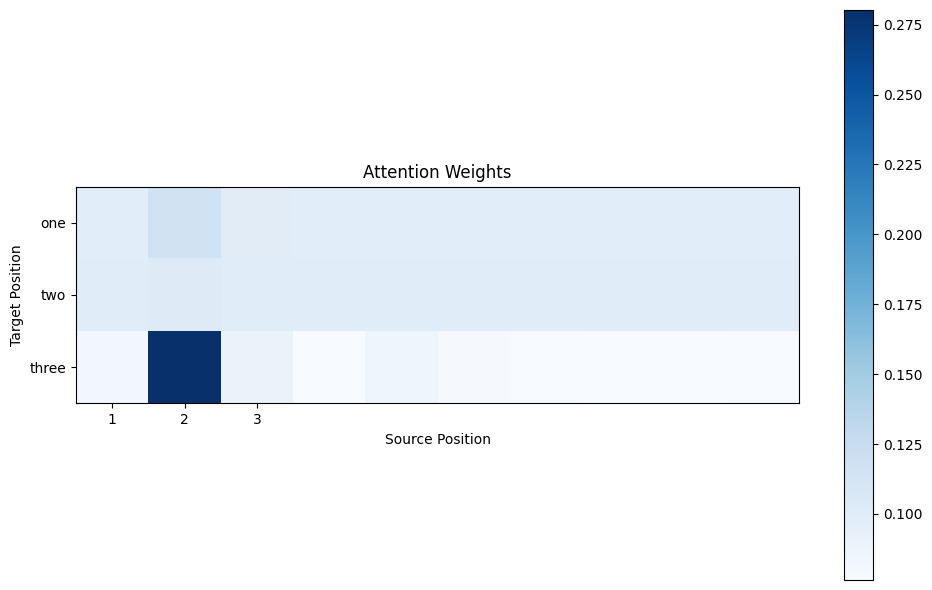

In [15]:
# 可视化注意力权重
plt.figure(figsize=(10, 6))
plt.imshow(attn, cmap='Blues')
plt.xlabel('Source Position')
plt.ylabel('Target Position')
plt.title('Attention Weights')
plt.xticks(range(len(src_text.split())), src_text.split())
plt.yticks(range(len(translated)), translated)
plt.colorbar()
plt.tight_layout()
plt.show()

## 总结

| 概念 | 说明 |
|------|------|
| Encoder | 将输入序列编码为隐藏状态序列 |
| Decoder | 逐步生成输出序列，每步输入上一步的预测/真实值 |
| Attention | 让解码器关注输入序列的不同部分，解决信息瓶颈 |
| Teacher Forcing | 训练时以一定概率使用真实标签作为解码器输入 |
| <sos>/<eos> | 序列开始/结束标记，控制解码的起始和终止 |

### Seq2Seq 的应用
- 机器翻译
- 文本摘要
- 对话系统
- 代码生成